In [ ]:
import os

# Define o nome da pasta principal
nome_projeto = "Analise_Pegada_Carbono"

# Define as subpastas em português
subpastas = [
    "dados/brutos",
    "dados/processados",
    "notebooks",
    "docs",
    "scripts"
]

# Cria a estrutura
if not os.path.exists(nome_projeto):
    os.makedirs(nome_projeto)
    print(f"✅ Pasta raiz '{nome_projeto}' criada.")

for pasta in subpastas:
    caminho = os.path.join(nome_projeto, pasta)
    if not os.path.exists(caminho):
        os.makedirs(caminho)
        print(f"  + Subpasta '{pasta}' criada.")

print("\n🚀 Estrutura pronta para começar o projeto!")


🚀 Estrutura pronta para começar o projeto!


In [ ]:
import pandas as pd

# 1. Definir o caminho exato onde o arquivo está
# CORREÇÃO: Usar o link 'raw' do GitHub para acessar o arquivo diretamente.
caminho_dados = 'https://raw.githubusercontent.com/carbon-footprint-analysis/carbon-footprint-analysis/main/notebooks/consumo_energia_emissoes_br.xlsx'

# 2. Carregar o dataset usando o pandas
df = pd.read_excel(caminho_dados)

# 3. Inspeção Visual
print("✅ Dataset carregado com sucesso!")
print(f"O arquivo contém {df.shape[0]} linhas e {df.shape[1]} colunas.\n")

print("--- Primeiras 5 linhas do Dataset ---")
display(df.head())

print("\n--- Resumo Técnico (Tipos de Dados e Nulos) ---")
df.info()

print("\n--- Estatísticas Descritivas Básicas ---")
display(df.describe())

✅ Dataset carregado com sucesso!
O arquivo contém 100000 linhas e 9 colunas.

--- Primeiras 5 linhas do Dataset ---


,company_id,date,state,usage_type,company_size,fuel_type,energy_kwh,energy_source,co2_emission
0,C400203,2025-10-25T00:00:00,BA,industrial,small,eletrico,41636.275320,wind,416.362753
1,C121611,2025-07-25T00:00:00,SP,industrial,small,eletrico,173135.729696,thermal,103881.437818
2,C963481,2025-10-28T00:00:00,SP,industrial,large,eletrico,65674.930115,hydro,1313.498602
3,C145272,2025-02-23T00:00:00,SP,comercial,medium,eletrico,1541.159336,hydro,30.823187
4,C240228,2025-09-26T00:00:00,DF,residencial,small,eletrico,104.944919,hydro,2.098898



--- Resumo Técnico (Tipos de Dados e Nulos) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   company_id     100000 non-null  object 
 1   date           100000 non-null  object 
 2   state          100000 non-null  object 
 3   usage_type     100000 non-null  object 
 4   company_size   100000 non-null  object 
 5   fuel_type      100000 non-null  object 
 6   energy_kwh     100000 non-null  float64
 7   energy_source  100000 non-null  object 
 8   co2_emission   100000 non-null  float64
dtypes: float64(2), object(7)
memory usage: 6.9+ MB

--- Estatísticas Descritivas Básicas ---


,energy_kwh,co2_emission
count,100000.000000,100000.000000
mean,18008.454847,2708.297297
std,27647.014992,9096.628021
min,50.067184,0.649168
25%,258.217932,11.990817
50%,2482.103857,121.643196
75%,29515.466138,774.199552
max,367659.792448,220595.875469


In [ ]:
# 1. Converter a coluna de data para o formato correto de data
df['date'] = pd.to_datetime(df['date'])

# 2. Converter colunas numéricas (forçando erro para NaN caso haja lixo no texto e depois tratando)
# Se houver vírgulas no lugar de pontos, o pandas pode se confundir, por isso usamos o replace
cols_numericas = ['energy_kwh', 'co2_emission']

for col in cols_numericas:
    # Caso os números venham com vírgula como separador decimal:
    df[col] = df[col].astype(str).str.replace(',', '.')
    # Converte para numérico
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Verificar se a conversão deu certo
print("✅ Conversão concluída!")
print("\n--- Novos Tipos de Dados ---")
print(df.dtypes)

print("\n--- Agora as estatísticas matemáticas funcionam! ---")
display(df.describe())

✅ Conversão concluída!

--- Novos Tipos de Dados ---
company_id               object
date             datetime64[ns]
state                    object
usage_type               object
company_size             object
fuel_type                object
energy_kwh              float64
energy_source            object
co2_emission            float64
dtype: object

--- Agora as estatísticas matemáticas funcionam! ---


,date,energy_kwh,co2_emission
count,100000,100000.000000,100000.000000
mean,2025-06-29 20:25:02.208000256,18008.454847,2708.297297
min,2025-01-01 00:00:00,50.067184,0.649168
25%,2025-03-28 00:00:00,258.217932,11.990817
50%,2025-06-28 00:00:00,2482.103857,121.643196
75%,2025-10-01 00:00:00,29515.466138,774.199552
max,2025-12-28 00:00:00,367659.792448,220595.875469
std,NaN,27647.014992,9096.628021


📊 RELATÓRIO EXECUTIVO DE EMISSÕES DE CO2

[1] EMISSÕES TOTAIS POR SETOR (kg CO2):
 - Industrial: 257,836,141.42 kg
 - Outros: 7,650,076.13 kg
 - Comercial: 3,984,908.26 kg
 - Residencial: 777,209.08 kg
 - Rural: 581,394.76 kg

[2] TOP 5 ESTADOS COM MAIORES EMISSÕES:
 - SP: 77,480,095.87 kg
 - MG: 46,524,549.13 kg
 - PR: 19,968,418.33 kg
 - PA: 16,344,117.11 kg
 - RS: 15,797,722.92 kg

[3] INTENSIDADE DE CARBONO POR FONTE (kg CO2/kWh):
 - Thermal: 0.6000 kg CO2/kWh
 - Hydro: 0.0200 kg CO2/kWh
 - Solar: 0.0200 kg CO2/kWh
 - Nuclear: 0.0100 kg CO2/kWh
 - Wind: 0.0100 kg CO2/kWh



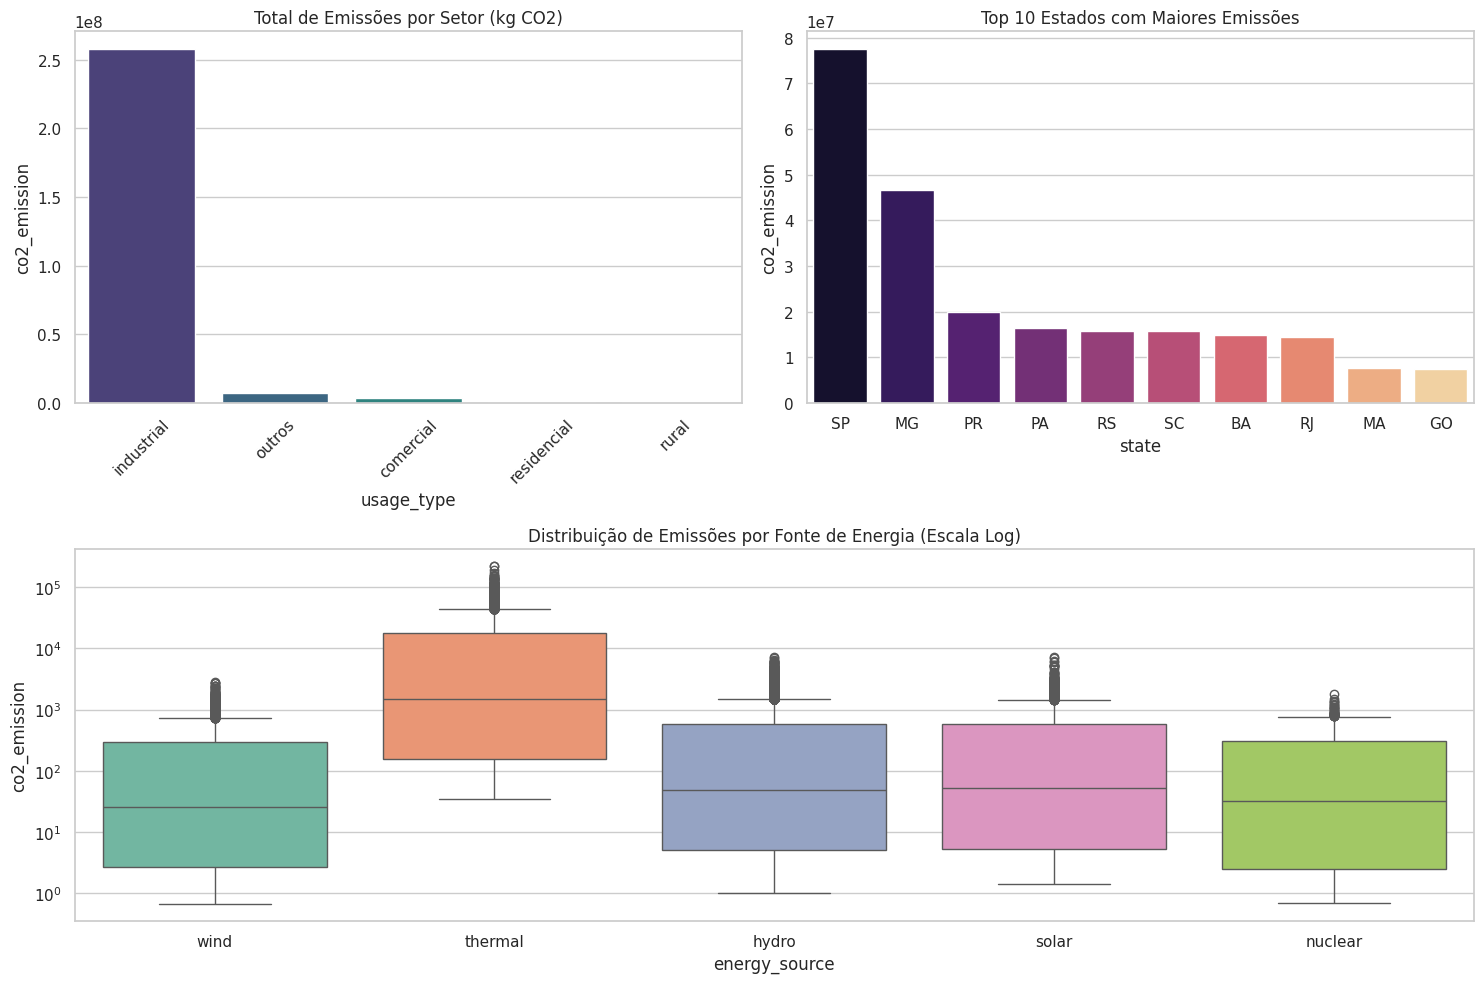

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Silencia avisos genéricos
warnings.filterwarnings('ignore', category=FutureWarning)

# --- 1. PREPARAÇÃO DOS DADOS PARA O RELATÓRIO ---
# Emissões por Setor
setor_emissao = df.groupby('usage_type')['co2_emission'].sum().sort_values(ascending=False).reset_index()

# Emissões por Estado (Top 5 para o console)
estado_emissao_full = df.groupby('state')['co2_emission'].sum().sort_values(ascending=False).reset_index()
top_estados = estado_emissao_full.head(10)

# Intensidade de Carbono
resumo_fontes = df.groupby('energy_source')[['co2_emission', 'energy_kwh']].sum()
intensidade = (resumo_fontes['co2_emission'] / resumo_fontes['energy_kwh']).sort_values(ascending=False)

# --- 2. RELATÓRIO POR ESCRITO NO CONSOLE ---
print("="*50)
print("📊 RELATÓRIO EXECUTIVO DE EMISSÕES DE CO2")
print("="*50)

print("\n[1] EMISSÕES TOTAIS POR SETOR (kg CO2):")
for index, row in setor_emissao.iterrows():
    print(f" - {row['usage_type'].capitalize()}: {row['co2_emission']:,.2f} kg")

print("\n[2] TOP 5 ESTADOS COM MAIORES EMISSÕES:")
for index, row in estado_emissao_full.head(5).iterrows():
    print(f" - {row['state']}: {row['co2_emission']:,.2f} kg")

print("\n[3] INTENSIDADE DE CARBONO POR FONTE (kg CO2/kWh):")
for fonte, valor in intensidade.items():
    print(f" - {fonte.capitalize()}: {valor:.4f} kg CO2/kWh")

print("\n" + "="*50)

# --- 3. PARTE VISUAL (GRÁFICOS) ---
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 10))

# Gráfico de Barras: Setor
plt.subplot(2, 2, 1)
sns.barplot(data=setor_emissao, x='usage_type', y='co2_emission', hue='usage_type', palette='viridis', legend=False)
plt.title('Total de Emissões por Setor (kg CO2)')
plt.xticks(rotation=45)

# Gráfico de Barras: Estado
plt.subplot(2, 2, 2)
sns.barplot(data=top_estados, x='state', y='co2_emission', hue='state', palette='magma', legend=False)
plt.title('Top 10 Estados com Maiores Emissões')

# Boxplot: Fonte de Energia
plt.subplot(2, 1, 2)
sns.boxplot(data=df, x='energy_source', y='co2_emission', hue='energy_source', palette='Set2', legend=False)
plt.yscale('log')
plt.title('Distribuição de Emissões por Fonte de Energia (Escala Log)')

plt.tight_layout()
plt.show()

✅ NOVA VARIÁVEL: IMPACTO AMBIENTAL
 - Baixo Impacto: 33000 registros (33.0%)
 - Médio Impacto: 33000 registros (33.0%)
 - Alto Impacto: 34000 registros (34.0%)

💾 Arquivo salvo com sucesso em:
/content/Analise_Pegada_Carbono/dados/processados/dados_energia_limpos.csv


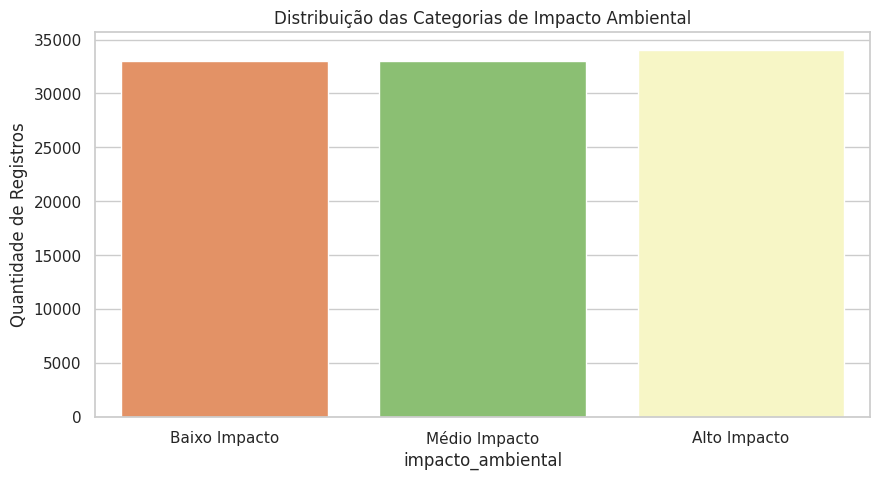

In [ ]:
import numpy as np

# 1. Criar a classificação baseada nos percentis das emissões
# Vamos dividir em 3 grupos iguais (33% cada)
limites = df['co2_emission'].quantile([0.33, 0.66]).values

def categorizar_impacto(valor):
    if valor <= limites[0]:
        return 'Baixo Impacto'
    elif valor <= limites[1]:
        return 'Médio Impacto'
    else:
        return 'Alto Impacto'

# Aplicar a função
df['impacto_ambiental'] = df['co2_emission'].apply(categorizar_impacto)

# 2. RELATÓRIO TEXTUAL DA NOVA COLUNA
print("="*50)
print("✅ NOVA VARIÁVEL: IMPACTO AMBIENTAL")
print("="*50)

contagem = df['impacto_ambiental'].value_counts()
porcentagem = df['impacto_ambiental'].value_counts(normalize=True) * 100

for cat in ['Baixo Impacto', 'Médio Impacto', 'Alto Impacto']:
    print(f" - {cat}: {contagem[cat]} registros ({porcentagem[cat]:.1f}%)")

print("\n" + "="*50)

# 3. SALVAR O DATASET PROCESSADO
caminho_processado = '/content/Analise_Pegada_Carbono/dados/processados/dados_energia_limpos.csv'
df.to_csv(caminho_processado, index=False)
print(f"💾 Arquivo salvo com sucesso em:\n{caminho_processado}")

# 4. VISUALIZAÇÃO DA DISTRIBUIÇÃO
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='impacto_ambiental', order=['Baixo Impacto', 'Médio Impacto', 'Alto Impacto'],
              hue='impacto_ambiental', palette='RdYlGn_r', legend=False)
plt.title('Distribuição das Categorias de Impacto Ambiental')
plt.ylabel('Quantidade de Registros')
plt.show()

🤖 RELATÓRIO DO MODELO PREDITIVO
               precision    recall  f1-score   support

 Alto Impacto       0.90      0.75      0.82      6774
Baixo Impacto       0.78      0.95      0.85      6644
Médio Impacto       0.72      0.68      0.70      6582

     accuracy                           0.79     20000
    macro avg       0.80      0.79      0.79     20000
 weighted avg       0.80      0.79      0.79     20000



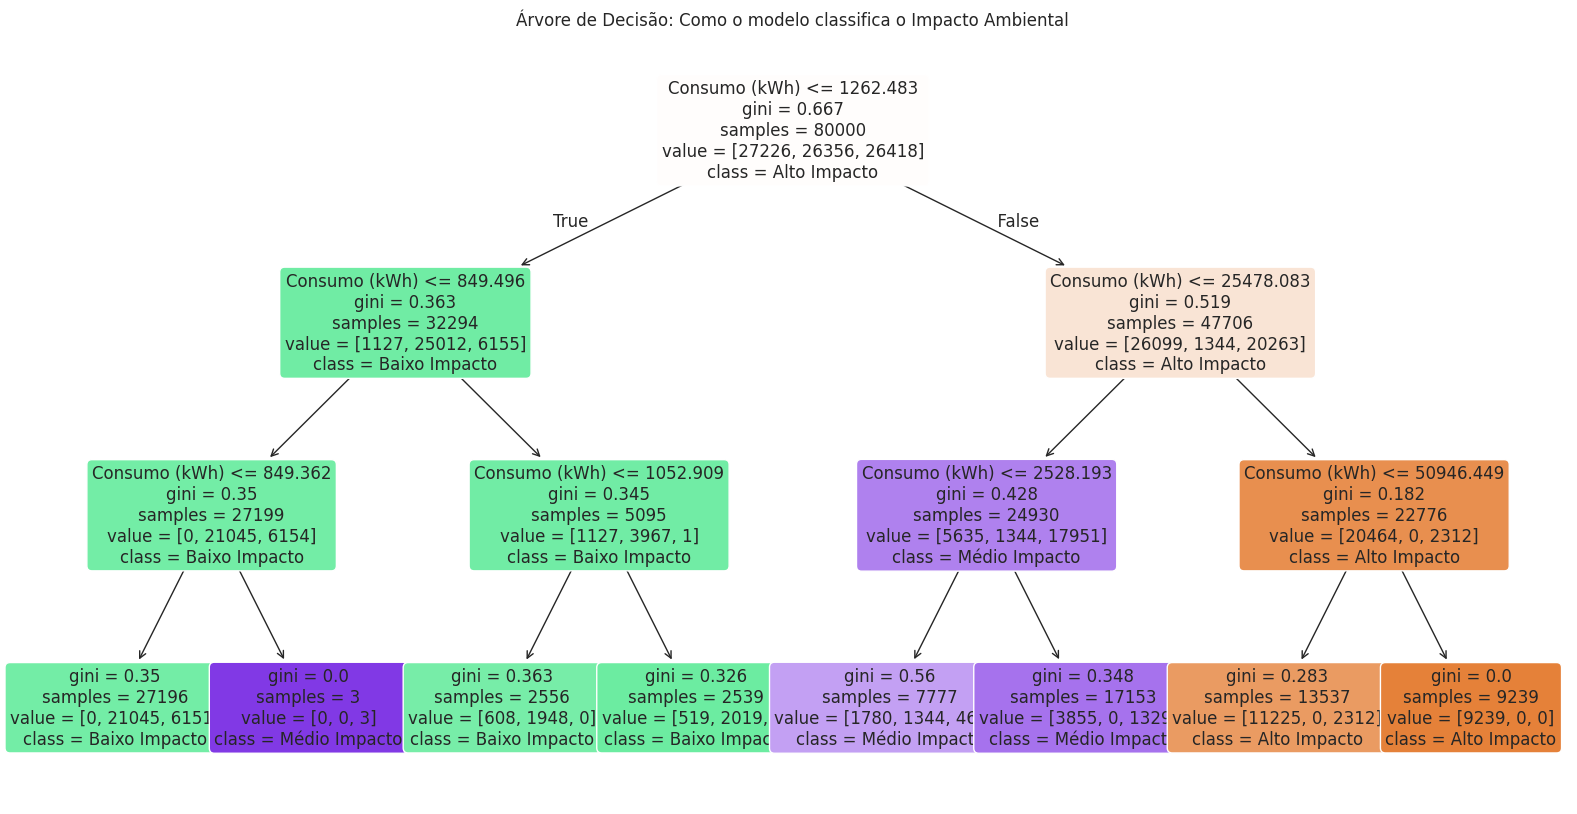

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix

# 1. PREPARAÇÃO DOS DADOS
# Vamos usar o consumo e o setor para prever o impacto ambiental
# Precisamos transformar o texto (setor) em números para o modelo entender
df_modelo = df.copy()
df_modelo['usage_type_encoded'] = df_modelo['usage_type'].astype('category').cat.codes

X = df_modelo[['energy_kwh', 'usage_type_encoded']]
y = df_modelo['impacto_ambiental']

# Dividir em Treino (80%) e Teste (20%)
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. TREINAMENTO DO MODELO
# Limitamos a profundidade (max_depth) para a árvore não ficar gigante e ser legível
modelo = DecisionTreeClassifier(max_depth=3, random_state=42)
modelo.fit(X_treino, y_treino)

# 3. RELATÓRIO DE DESEMPENHO NO CONSOLE
print("="*50)
print("🤖 RELATÓRIO DO MODELO PREDITIVO")
print("="*50)
previsoes = modelo.predict(X_teste)
print(classification_report(y_teste, previsoes))

# 4. VISUALIZAÇÃO DA ÁRVORE (O "MAPA" DA DECISÃO)
plt.figure(figsize=(20,10))
plot_tree(modelo, feature_names=['Consumo (kWh)', 'Tipo de Uso'],
          class_names=modelo.classes_, filled=True, rounded=True, fontsize=12)
plt.title("Árvore de Decisão: Como o modelo classifica o Impacto Ambiental")
plt.show()

========================================================

EDA synthetic_energy_emissions_dataset.csv

In [75]:
import pandas as pd

In [76]:
url = 'https://raw.githubusercontent.com/carbon-footprint-analysis/carbon-footprint-analysis/refs/heads/feature/eda-analysis/data/processed/synthetic_energy_emissions_dataset.csv'
raw = pd.read_csv(url).drop(columns=["Unnamed: 0"])

In [77]:
raw

,company_id,date,state,usage_type,company_size,fuel_type,energy_kwh,energy_source,co2_emission
0,C655911,2025-07-22,RJ,residencial,small,eletrico,212.354196,hydro,3.723687
1,C251943,2025-11-16,PE,comercial,large,eletrico,3409.511719,hydro,72.461246
2,C411294,2025-03-25,SE,residencial,small,eletrico,169.153796,solar,3.100362
3,C314886,2025-11-19,SP,industrial,medium,eletrico,29070.245558,hydro,586.846101
4,C245542,2025-12-11,SC,comercial,large,eletrico,1741.506642,wind,18.879442
...,...,...,...,...,...,...,...,...,...
99995,C330797,2025-07-16,PR,residencial,small,eletrico,156.099140,hydro,3.532847
99996,C893381,2025-11-25,RS,residencial,small,eletrico,220.649203,hydro,4.879418
99997,C555148,2025-07-25,PR,industrial,small,eletrico,47194.193327,solar,914.114063
99998,C732188,2025-11-21,GO,residencial,small,eletrico,152.204073,solar,3.003354


In [78]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   company_id     100000 non-null  object 
 1   date           100000 non-null  object 
 2   state          100000 non-null  object 
 3   usage_type     100000 non-null  object 
 4   company_size   100000 non-null  object 
 5   fuel_type      100000 non-null  object 
 6   energy_kwh     100000 non-null  float64
 7   energy_source  100000 non-null  object 
 8   co2_emission   100000 non-null  float64
dtypes: float64(2), object(7)
memory usage: 6.9+ MB


Tipagem das colunas
| coluna        | tipo ideal |
| ------------- | ---------- |
| company_id    | category   |
| date          | datetime   |
| state         | category   |
| usage_type    | category   |
| company_size  | category   |
| fuel_type     | category   |
| energy_kwh    | float      |
| energy_source | category   |
| co2_emission  | float      |


In [79]:
raw["date"] = pd.to_datetime(raw["date"])

categorical_cols = [
"company_id",
"state",
"usage_type",
"company_size",
"fuel_type",
"energy_source"
]

for col in categorical_cols:
    raw[col] = raw[col].astype("category")

In [80]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   company_id     100000 non-null  category      
 1   date           100000 non-null  datetime64[ns]
 2   state          100000 non-null  category      
 3   usage_type     100000 non-null  category      
 4   company_size   100000 non-null  category      
 5   fuel_type      100000 non-null  category      
 6   energy_kwh     100000 non-null  float64       
 7   energy_source  100000 non-null  category      
 8   co2_emission   100000 non-null  float64       
dtypes: category(6), datetime64[ns](1), float64(2)
memory usage: 5.9 MB


ETL leve

add região

In [81]:
region_map = {
"RS":"sul","SC":"sul","PR":"sul",
"SP":"sudeste","RJ":"sudeste","MG":"sudeste","ES":"sudeste",
"GO":"centro-oeste","MT":"centro-oeste","MS":"centro-oeste","DF":"centro-oeste",
"BA":"nordeste","PE":"nordeste","CE":"nordeste","RN":"nordeste","PB":"nordeste","AL":"nordeste","SE":"nordeste","MA":"nordeste","PI":"nordeste",
"AM":"norte","PA":"norte","AC":"norte","RO":"norte","RR":"norte","AP":"norte","TO":"norte"
}

raw["region"] = raw["state"].map(region_map)

add mes

In [82]:
raw["month"] = raw["date"].dt.month

add estação

In [83]:
def season(m):
    if m in [12,1,2]:
        return "verao"
    if m in [3,4,5]:
        return "outono"
    if m in [6,7,8]:
        return "inverno"
    return "primavera"

raw["season"] = raw["month"].apply(season)

add qtd de carbono pro kwh (medir se energia é limpa)

In [84]:
raw["carbon_intensity"] = raw["co2_emission"] / raw["energy_kwh"]

apagar coluna data, os dias foram gerados de maneira que não agregam nada inclusive acontece o contrario porque os dados que tivemos para gerar sinteticamente tem como variavel temporal o mes !

In [85]:
raw = raw.drop(columns=["date"])

In [86]:
raw.head()

,company_id,state,usage_type,company_size,fuel_type,energy_kwh,energy_source,co2_emission,region,month,season,carbon_intensity
0,C655911,RJ,residencial,small,eletrico,212.354196,hydro,3.723687,sudeste,7,inverno,0.017535
1,C251943,PE,comercial,large,eletrico,3409.511719,hydro,72.461246,nordeste,11,primavera,0.021253
2,C411294,SE,residencial,small,eletrico,169.153796,solar,3.100362,nordeste,3,outono,0.018329
3,C314886,SP,industrial,medium,eletrico,29070.245558,hydro,586.846101,sudeste,11,primavera,0.020187
4,C245542,SC,comercial,large,eletrico,1741.506642,wind,18.879442,sul,12,verao,0.010841


EDA

Distribuições

tipo de uso

In [87]:
raw["usage_type"].value_counts()

,count
usage_type,
industrial,38894
residencial,27940
comercial,17724
outros,10155
rural,5287


<Axes: title={'center': 'Distribuiçao tipo de uso'}>

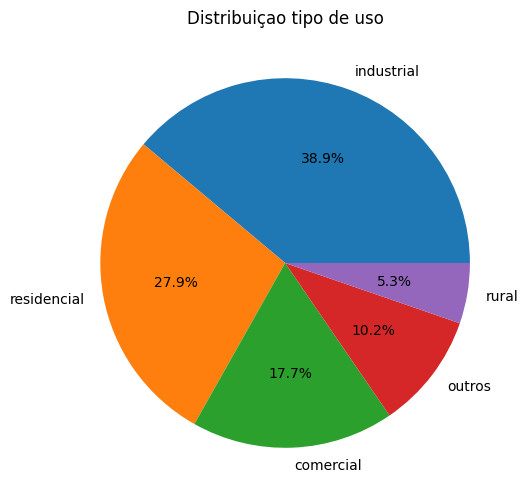

In [119]:
raw["usage_type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6),
    ylabel="",
    title="Distribuiçao tipo de uso"
)

fonte energia

In [88]:
raw["energy_source"].value_counts()

,count
energy_source,
hydro,51654
thermal,22777
wind,15856
solar,8717
nuclear,996


<Axes: title={'center': 'Proporção fonte de energia '}>

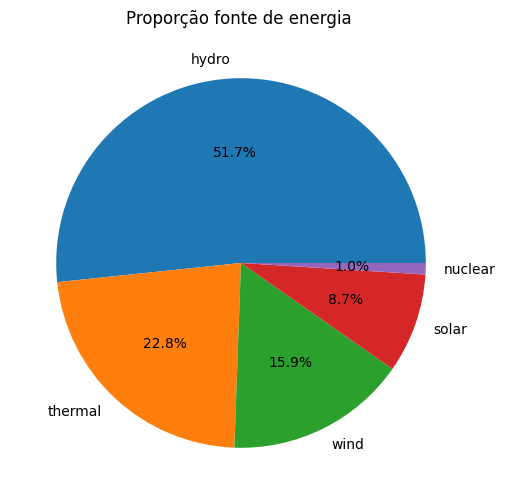

In [120]:
raw["energy_source"].value_counts(normalize=True).plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6),
    ylabel="",
    title="Proporção fonte de energia "
)

estatisticas de consumo

In [89]:
raw["energy_kwh"].describe()

,energy_kwh
count,100000.000000
mean,18035.071206
std,27800.927954
min,51.207212
25%,261.796455
50%,2489.399170
75%,29264.769288
max,320325.893064


consumo por setor

In [90]:
raw.groupby("usage_type")["energy_kwh"].mean().sort_values()

/tmp/ipykernel_9402/4226823955.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  raw.groupby("usage_type")["energy_kwh"].mean().sort_values()


,energy_kwh
usage_type,
residencial,186.422267
rural,711.639377
comercial,1494.899803
outros,5165.667553
industrial,44109.196455


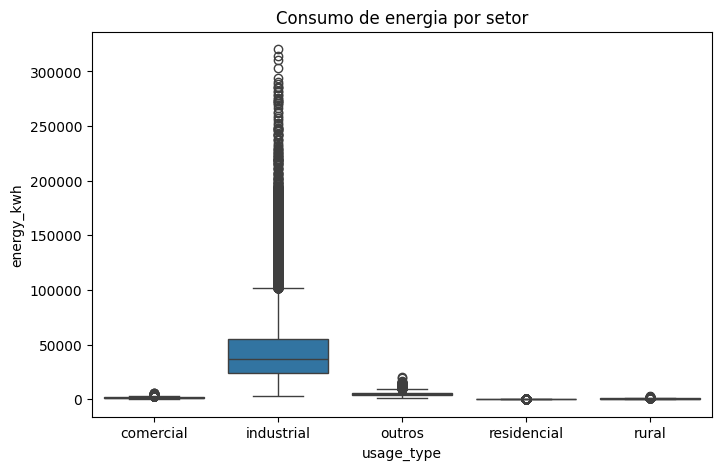

In [91]:
plt.figure(figsize=(8,5))
sns.boxplot(data=raw, x="usage_type", y="energy_kwh")
plt.title("Consumo de energia por setor")
plt.show()

emissão  co² por fonte de energia

In [92]:
raw.groupby("energy_source")["co2_emission"].mean().sort_values()

/tmp/ipykernel_9402/1220726412.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  raw.groupby("energy_source")["co2_emission"].mean().sort_values()


,co2_emission
energy_source,
nuclear,174.953426
wind,180.875973
solar,357.266360
hydro,360.361927
thermal,10862.958446


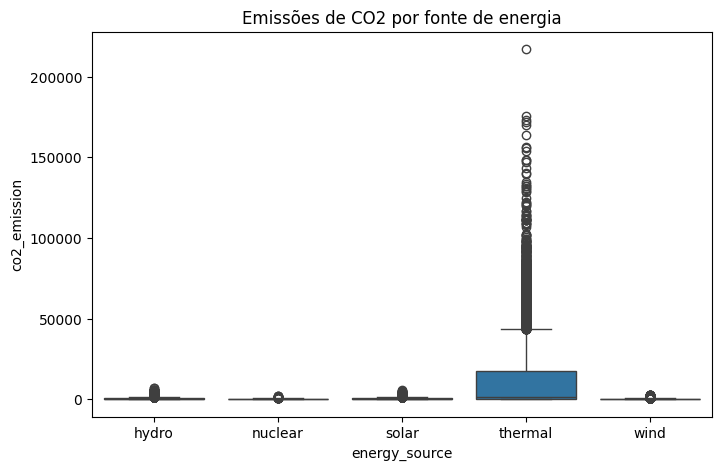

In [93]:
plt.figure(figsize=(8,5))
sns.boxplot(data=raw, x="energy_source", y="co2_emission")
plt.title("Emissões de CO2 por fonte de energia")
plt.show()

<Axes: xlabel='carbon_intensity', ylabel='energy_kwh'>

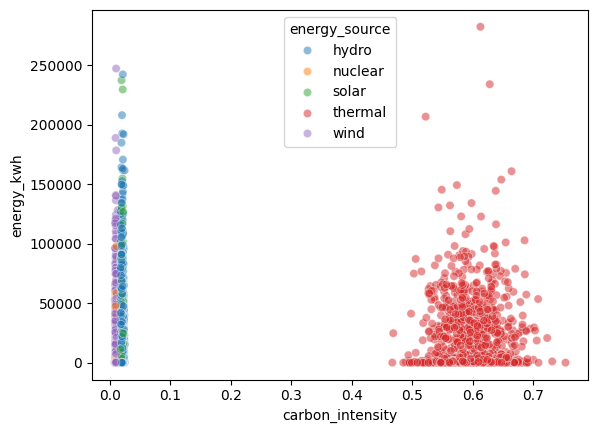

In [103]:
sns.scatterplot(
    data=raw.sample(5000),
    x="carbon_intensity",
    y="energy_kwh",
    hue="energy_source",
    alpha=0.5
)

<Axes: xlabel='carbon_intensity', ylabel='Count'>

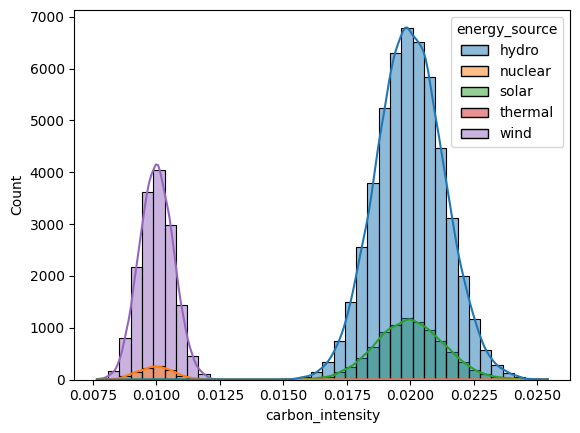

In [108]:
clean = raw[raw["carbon_intensity"] < 0.1]

sns.histplot(
    data=clean,
    x="carbon_intensity",
    hue="energy_source",
    bins=40,
    kde=True
)

emissão co²por região

In [94]:
raw.groupby("region")["co2_emission"].mean().sort_values()

,co2_emission
region,
centro-oeste,1924.649583
nordeste,2476.971516
sul,2617.294224
sudeste,2900.782465
norte,3109.120877


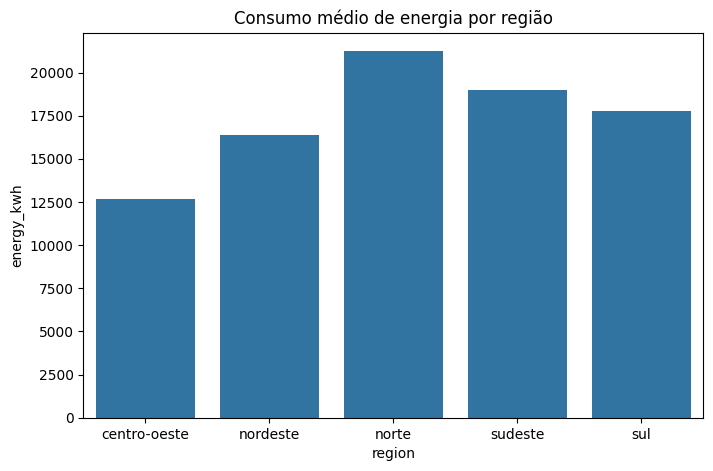

In [95]:
region_energy = raw.groupby("region")["energy_kwh"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=region_energy, x="region", y="energy_kwh")
plt.title("Consumo médio de energia por região")
plt.show()

emissão por estação

In [96]:
raw.groupby("season")["co2_emission"].mean().sort_values()

,co2_emission
season,
primavera,2688.232860
outono,2701.360187
verao,2705.333564
inverno,2793.293530


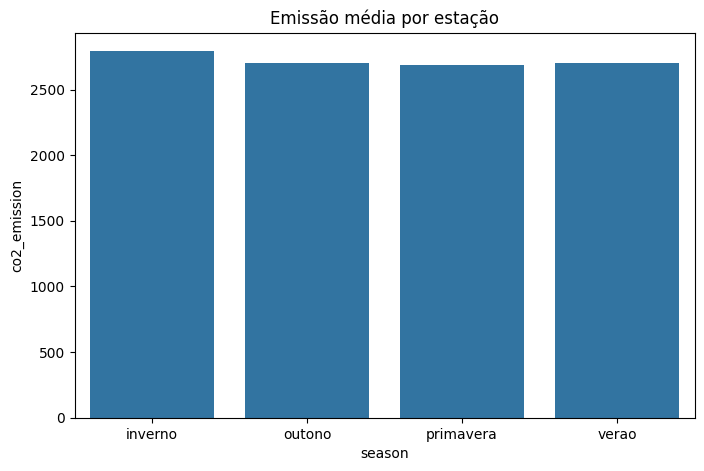

In [97]:
season_emission = raw.groupby("season")["co2_emission"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=season_emission, x="season", y="co2_emission")
plt.title("Emissão média por estação")
plt.show()

intensidade de carbono por fonte

In [98]:
raw.groupby("energy_source")["carbon_intensity"].mean()

/tmp/ipykernel_9402/1116575236.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  raw.groupby("energy_source")["carbon_intensity"].mean()


,carbon_intensity
energy_source,
hydro,0.019990
nuclear,0.009955
solar,0.019991
thermal,0.600092
wind,0.010002


/tmp/ipykernel_9402/4169981311.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  carbon_source = raw.groupby("energy_source")["carbon_intensity"].mean().reset_index()


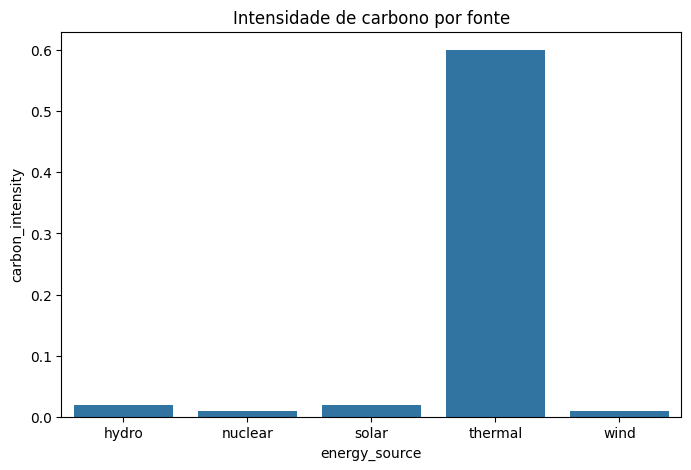

In [99]:
carbon_source = raw.groupby("energy_source")["carbon_intensity"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=carbon_source, x="energy_source", y="carbon_intensity")
plt.title("Intensidade de carbono por fonte")
plt.show()

Emissão Co² total anual

In [112]:
co2_by_source = raw.groupby("energy_source")["co2_emission"].sum().sort_values()
co2_by_source

/tmp/ipykernel_9402/2516710284.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  co2_by_source = raw.groupby("energy_source")["co2_emission"].sum().sort_values()


,co2_emission
energy_source,
nuclear,1.742536e+05
wind,2.867969e+06
solar,3.114291e+06
hydro,1.861413e+07
thermal,2.474256e+08


/tmp/ipykernel_9402/3106925516.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  raw.groupby("energy_source")["co2_emission"]


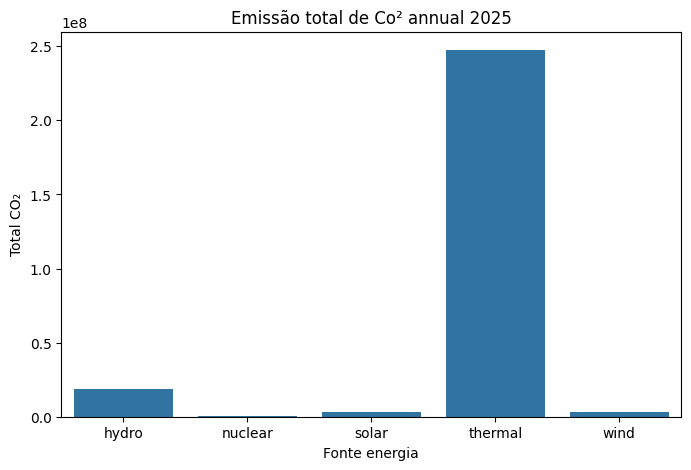

In [114]:
co2_by_source = (
    raw.groupby("energy_source")["co2_emission"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=co2_by_source.index,
    y=co2_by_source.values
)

plt.title("Emissão total de Co² annual 2025")
plt.ylabel("Total CO₂")
plt.xlabel("Fonte energia")

plt.show()